In [1]:
# Task 1: Exploratory Data Analysis(EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("glass_csv.csv")

In [3]:
print("\nStatistical Summary:\n", df.describe())


Statistical Summary:
                RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000   
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500   
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000   
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   
max      1.533930   17.380000    4.490000    3.500000   75.410000    6.210000   

               Ca          Ba          Fe        Type  
count  214.000000  214.000000  214.000000  214.000000  
mean     8.956963    0.175047    0.057009    2.780374  
std      1.423153    0.497219    0.097439    2.103739  
min      5.430000    0.

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    float64
dtypes: float64(10)
memory usage: 78.2 KB
None


In [5]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 RI      785
Na      785
Mg      785
Al      785
Si      785
K       785
Ca      785
Ba      785
Fe      785
Type    785
dtype: int64


In [9]:
cols_to_check = ['RI','Na','Mg','Al','Si','K','Ca','Ba','Fe']
df[cols_to_check] = df[cols_to_check].replace(0, np.nan)

In [10]:
df.fillna(df.median(), inplace=True)

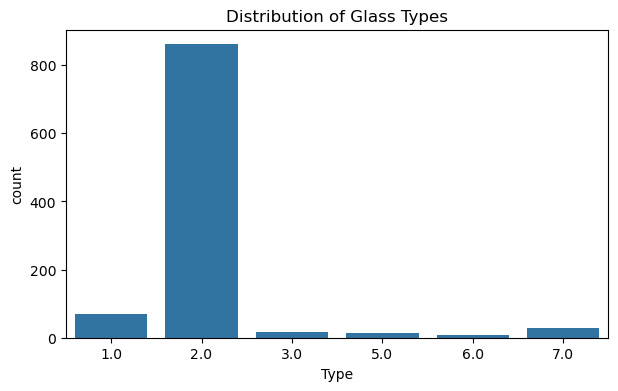

In [11]:
plt.figure(figsize=(7,4))
sns.countplot(x='Type', data=df)
plt.title("Distribution of Glass Types")
plt.show()

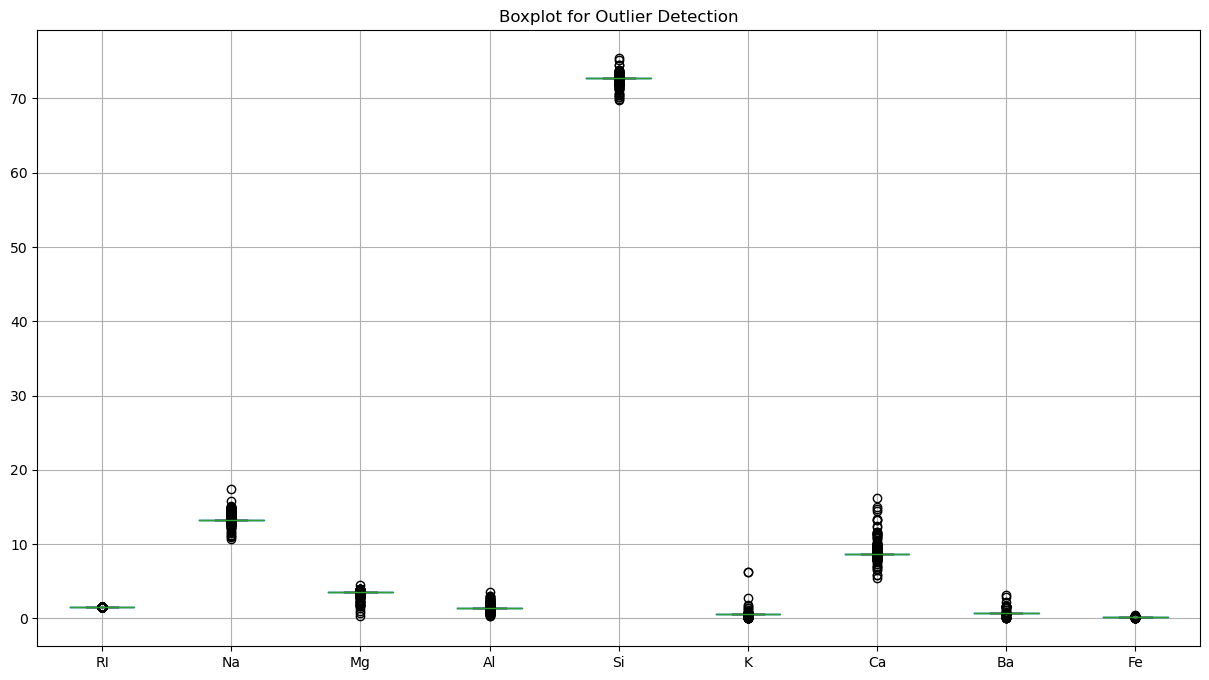

In [13]:
numeric_cols = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']
plt.figure(figsize=(15,8))
df.boxplot(column=numeric_cols)
plt.title("Boxplot for Outlier Detection")
plt.show()

In [14]:
# Task 2: Data Visualization

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

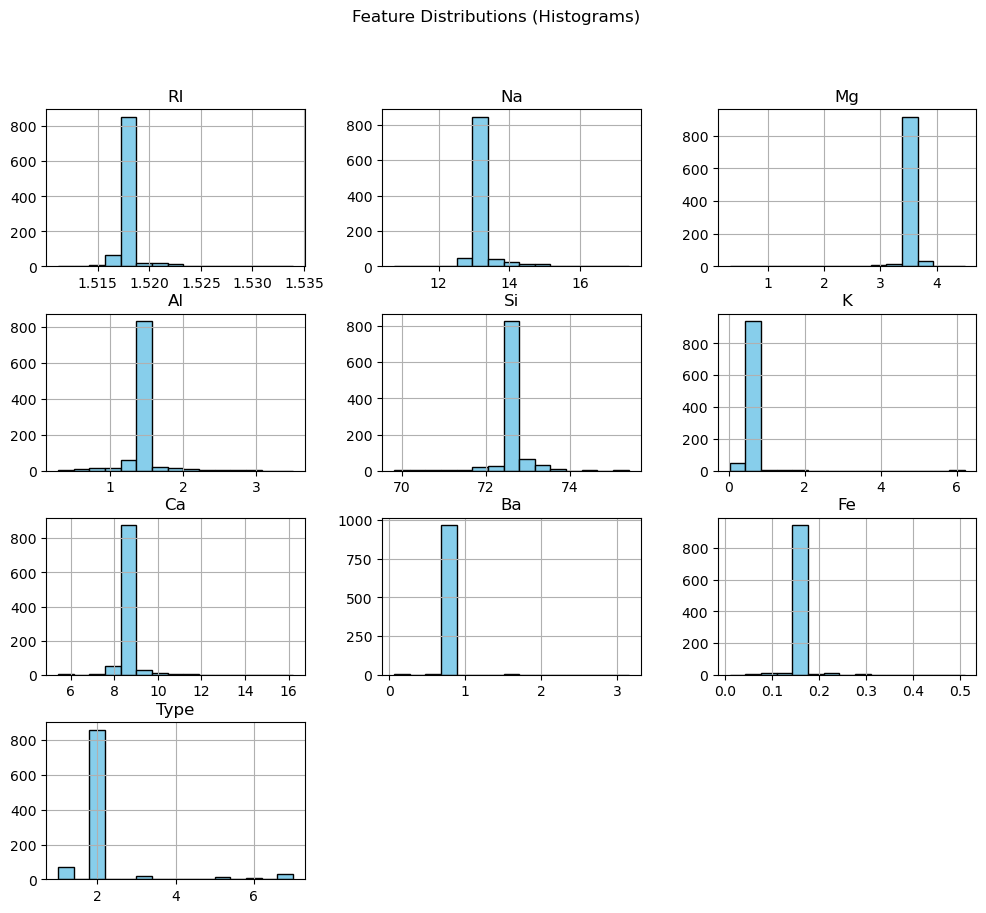

In [17]:
df.hist(figsize=(12, 10), bins=15, color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions (Histograms)")
plt.show()

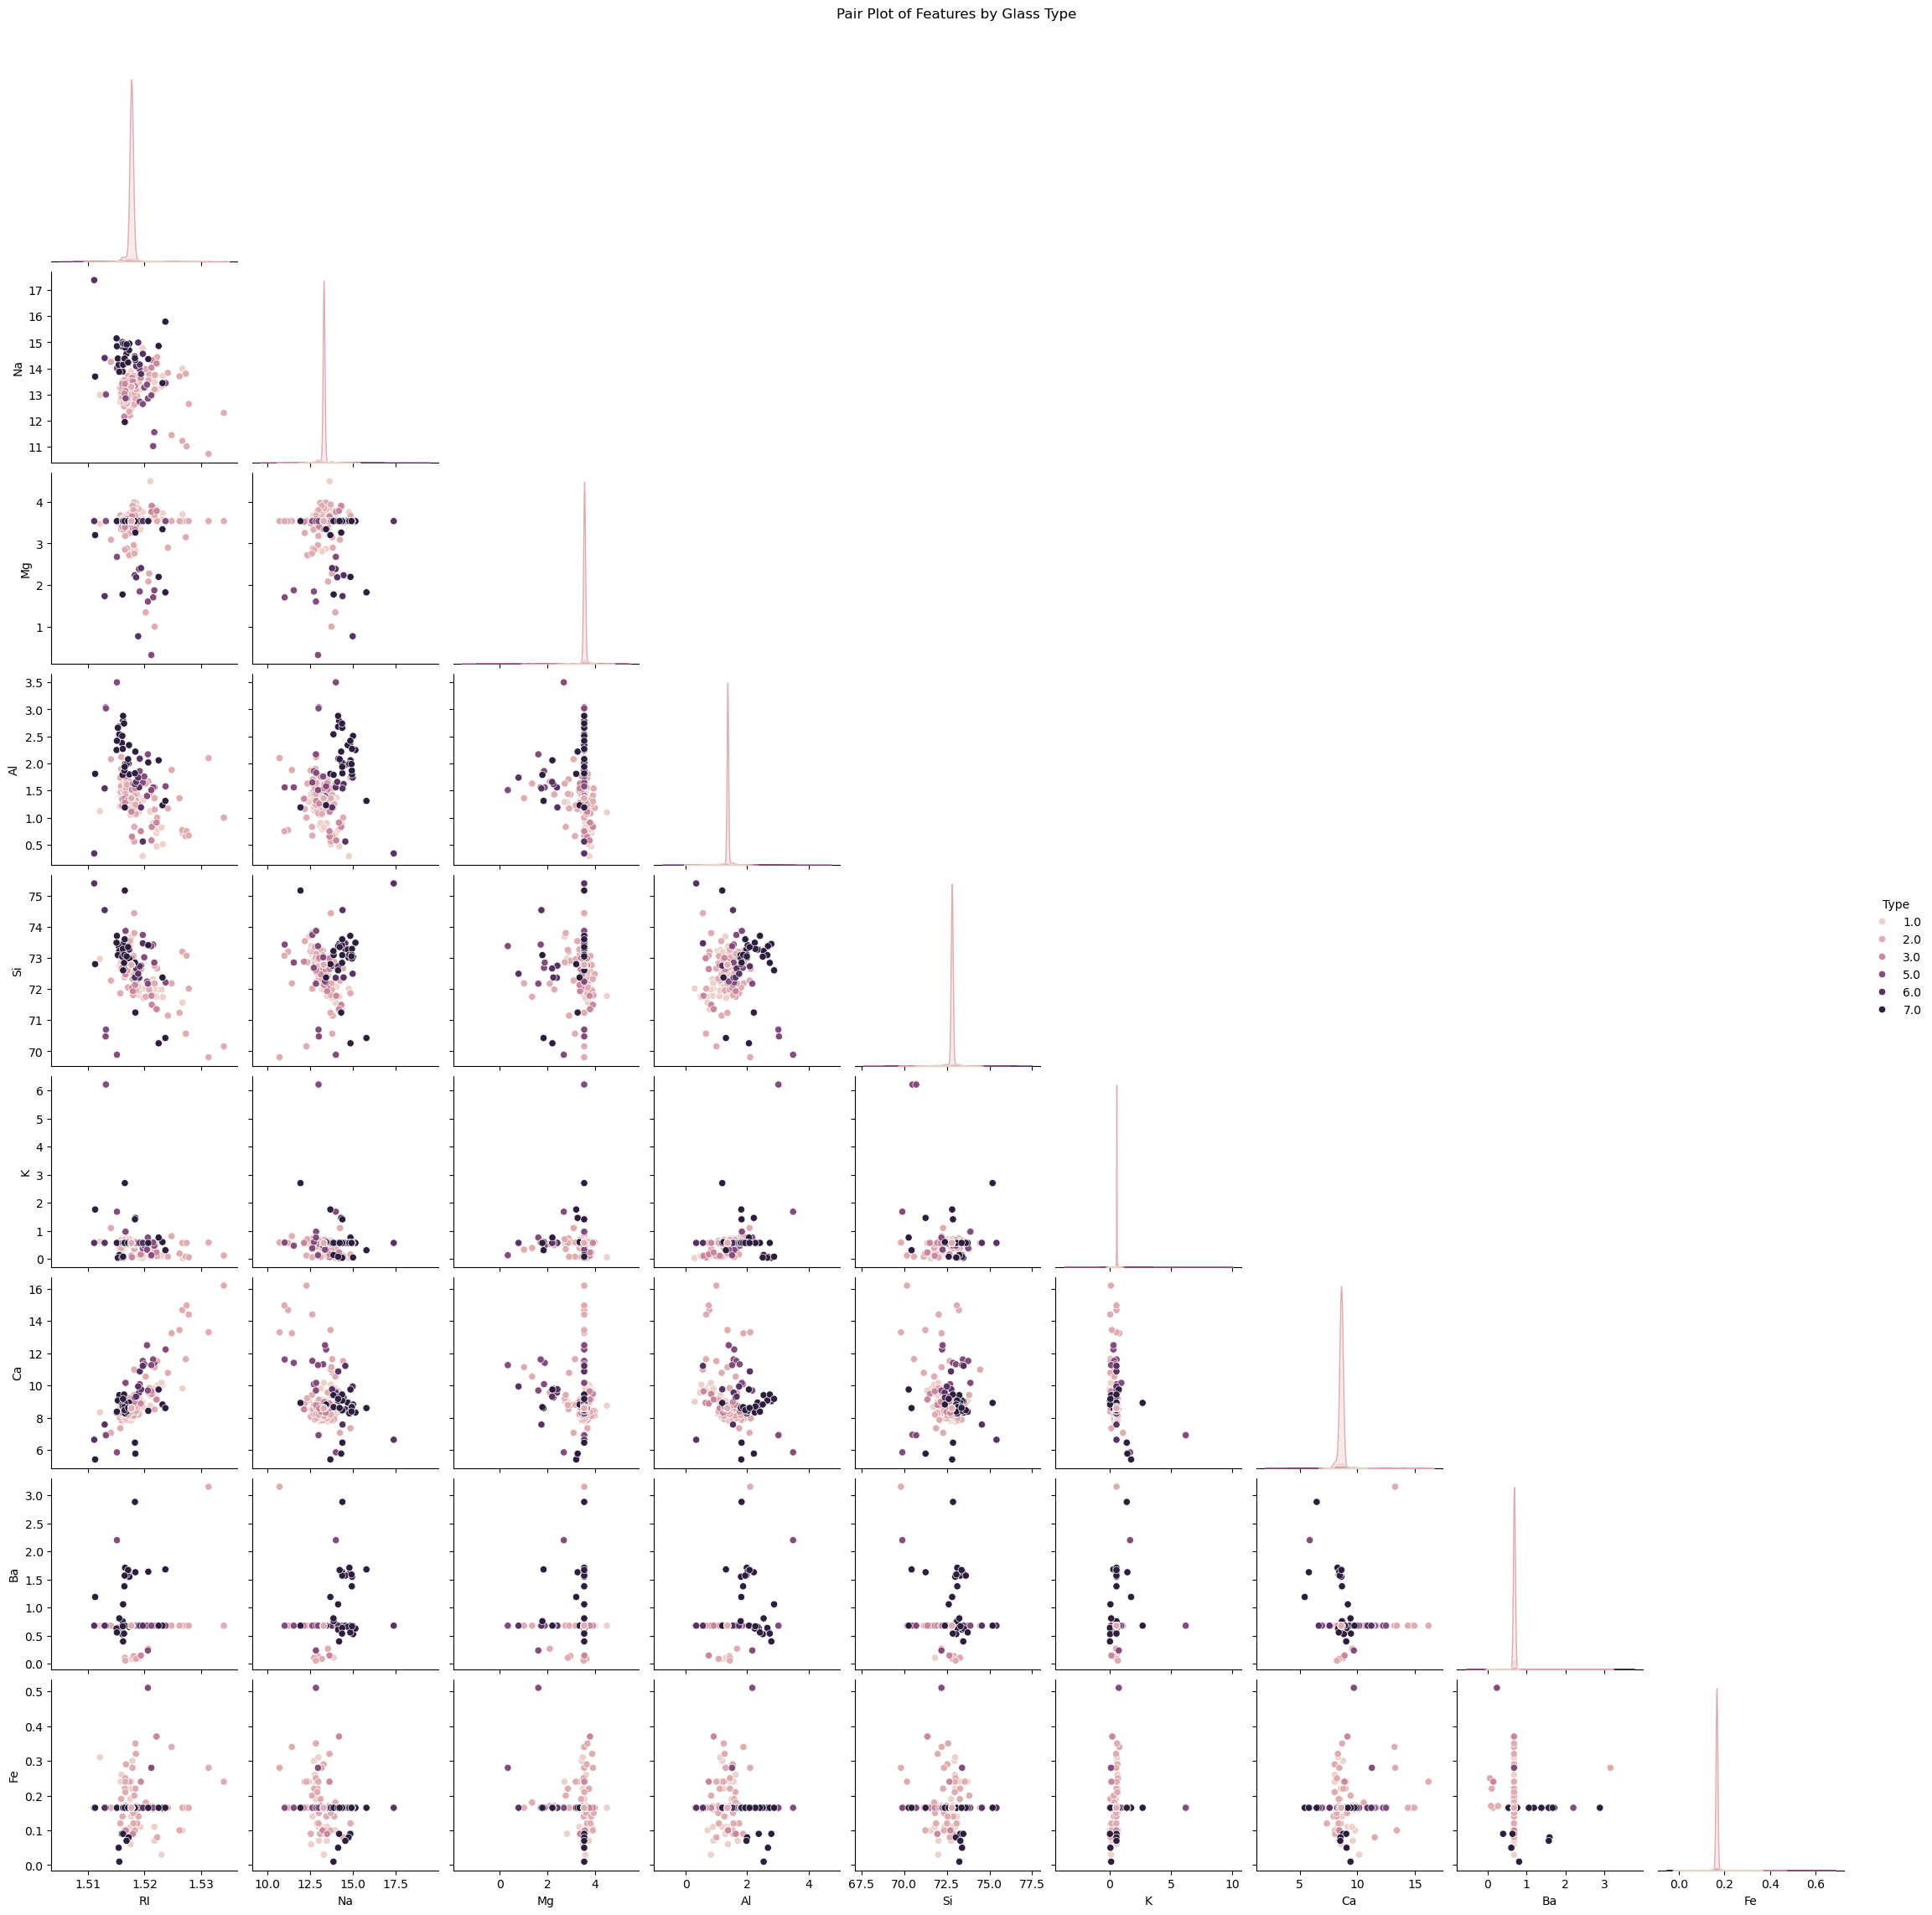

In [18]:
sns.pairplot(df, hue='Type', diag_kind='kde', corner=True)
plt.suptitle("Pair Plot of Features by Glass Type", y=1.02)
plt.show()

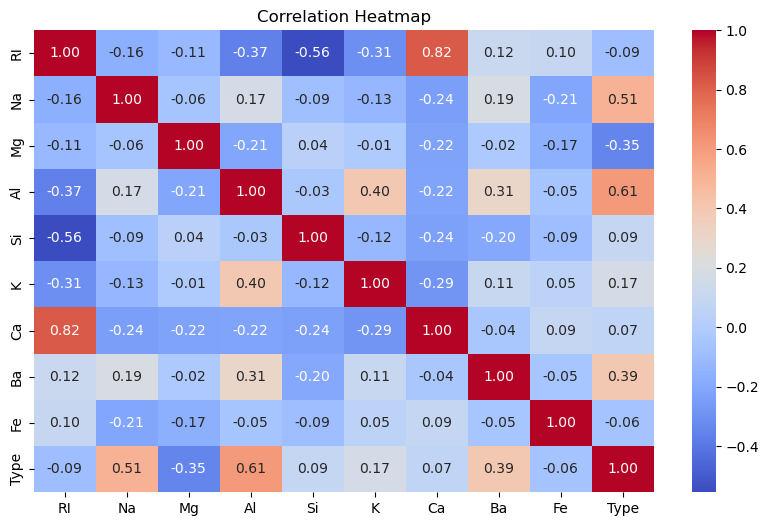

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [22]:
# Outliers are present in Na,K and Ca. But they are normal and can be ignored.
# RI and Ca are highly correlated as seen in heatmap.
# There is class imbalance as seen in our target variable that is Type column.

In [23]:
# Task #: Data Pre-processing

In [24]:
# There were missing values in columns and they were handled by imputation.
# The reason behind it is the missing values were actually zeros and it does not exactly mean missing.
# Hence we cannot directly remove them.
# There are no categorail values in dataset. No encoding required.

In [25]:
from sklearn.preprocessing import StandardScaler
X = df.drop('Type', axis=1)
y = df['Type']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
# Task 4: Random Forest Model Implementation

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [28]:
y_pred = rf.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Accuracy: 0.910
Precision: 0.616
Recall: 0.492
F1-score: 0.536


In [30]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

         1.0       0.75      0.64      0.69        14
         2.0       0.94      0.98      0.96       172
         3.0       0.00      0.00      0.00         3
         5.0       0.50      0.33      0.40         3
         6.0       1.00      0.50      0.67         2
         7.0       0.50      0.50      0.50         6

    accuracy                           0.91       200
   macro avg       0.62      0.49      0.54       200
weighted avg       0.90      0.91      0.90       200



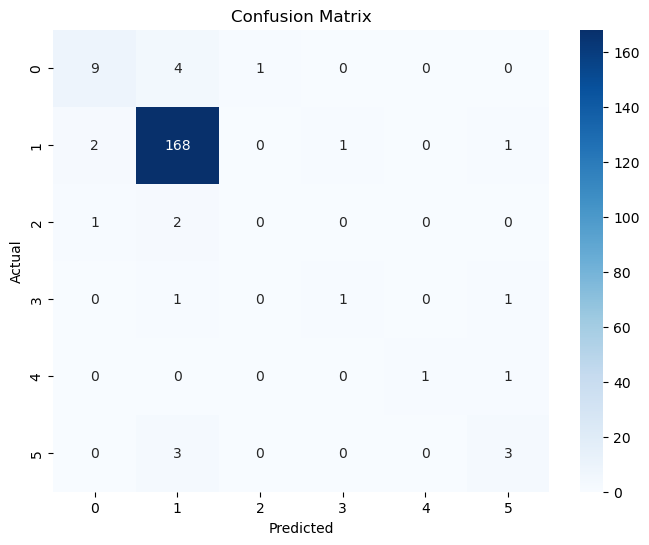

In [31]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [32]:
# Task 5: Bagging and Boosting Methods

In [34]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import classification_report, accuracy_score

bagging = BaggingClassifier(
    n_estimators=100,      
    random_state=42
)

bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_test)

accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
print("Bagging Accuracy:", accuracy_bagging)
print("\nBagging Classification Report:\n")
print(classification_report(y_test, y_pred_bagging,zero_division=0))

Bagging Accuracy: 0.925

Bagging Classification Report:

              precision    recall  f1-score   support

         1.0       0.73      0.79      0.76        14
         2.0       0.96      0.98      0.97       172
         3.0       0.00      0.00      0.00         3
         5.0       0.67      0.67      0.67         3
         6.0       1.00      0.50      0.67         2
         7.0       0.50      0.50      0.50         6

    accuracy                           0.93       200
   macro avg       0.64      0.57      0.59       200
weighted avg       0.91      0.93      0.92       200



In [36]:
from sklearn.ensemble import AdaBoostClassifier

adaboost = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

adaboost.fit(X_train, y_train)
y_pred_ada = adaboost.predict(X_test)

accuracy_ada = accuracy_score(y_test, y_pred_ada)
print("AdaBoost Accuracy:", accuracy_ada)
print("\nAdaBoost Classification Report:\n")
print(classification_report(y_test, y_pred_ada,zero_division=0))

AdaBoost Accuracy: 0.88

AdaBoost Classification Report:

              precision    recall  f1-score   support

         1.0       0.67      0.14      0.24        14
         2.0       0.90      0.99      0.94       172
         3.0       0.00      0.00      0.00         3
         5.0       0.00      0.00      0.00         3
         6.0       0.00      0.00      0.00         2
         7.0       0.50      0.50      0.50         6

    accuracy                           0.88       200
   macro avg       0.34      0.27      0.28       200
weighted avg       0.83      0.88      0.84       200



In [37]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", accuracy_gb)
print("\nGradient Boosting Classification Report:\n")
print(classification_report(y_test, y_pred_gb,zero_division=0))

Gradient Boosting Accuracy: 0.915

Gradient Boosting Classification Report:

              precision    recall  f1-score   support

         1.0       0.67      0.71      0.69        14
         2.0       0.97      0.97      0.97       172
         3.0       0.00      0.00      0.00         3
         5.0       0.50      0.33      0.40         3
         6.0       1.00      0.50      0.67         2
         7.0       0.50      0.67      0.57         6

    accuracy                           0.92       200
   macro avg       0.61      0.53      0.55       200
weighted avg       0.91      0.92      0.91       200



In [38]:
# Before we applied bagging and boosting methods, our mode showed 91% accuracy. It performed well with majority(Type2) data.
# But for minority(Type 3,5,6,7) it does not do well as we see low recall and precision values.
# For handling imbalance in dataset, we added bagging and boosting methods.
# Among those, Bagging showed highest accuracy of 92.5%.
# Bagging handles minority values by reducing variances.

In [42]:
# 1. Explain Bagging and Boosting methods. How is it different from each other?
# ---> A] Bagging :
#         i) Bagging is an ensemble learning method that combines the predictions of multiple independent base models 
#            (usually Decision Trees) trained on different bootstrap samples of the dataset.
#         ii) It reduces variance of unstable models like decision trees.
#         iii) It helps prevent overfitting.
#         iv) Examples: Random Forest, BaggingClassifier.
#          v) It's approach is parallel training of data.
#----> B] Boosting :
#         i) Boosting is an ensemble learning method that combines multiple weak learners sequentially, 
#            where each learner focuses on correcting errors made by previous learners.
#         ii) It reduces bias and improves accuracy.
#         iii) It can overfit if too many learners or high depth trees are used.
#         iv) Examples: AdaBoost, Gradient Boosting, XGBoost, LightGBM.
#          v) It's approach is sequential training of data.

In [43]:
# 2. Explain how to handle imbalance in the data.
# ---> Strategies to Handle Imbalance :- 
#            A. Algorithm-level Approaches:
#                   I) Class Weights - It assigns higher weight to minority classes in loss function.
#                      Example in Random Forest: class_weight='balanced'.
#                   II) Cost-sensitive Learning - It penalizes misclassification of minority classes more heavily.
#            B. Evaluation Metrics:
#                   I) Use metrics that reflect minority class performance:
#                       i)Precision, Recall, F1-score (macro or weighted)
#                       ii) Confusion Matrix